<a href="https://colab.research.google.com/github/Anisha32414/Deep-Learning/blob/main/ANN_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [69]:
!pip install tensorflow

In [70]:
import tensorflow as tf

print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))

2.20.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [71]:
## import some basic lib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



In [72]:
dataset=pd.read_csv('Churn_Modelling.csv')
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [73]:
## divide the dataset into dependent and independent features
x=dataset.iloc[:,3:13]
y=dataset.iloc[:,13]


In [74]:
x.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [75]:
y

,Exited
0,1
1,0
2,1
3,0
4,0
...,...
9995,0
9996,0
9997,1
9998,1


In [76]:
## Feature Engineering
geography=pd.get_dummies(x['Geography'],drop_first=True)
gender=pd.get_dummies(x['Gender'],drop_first=True)

In [77]:
gender

,Male
0,False
1,False
2,False
3,False
4,False
...,...
9995,True
9996,True
9997,False
9998,True


In [78]:
## Concatenate these variables with dataframes
x=x.drop(['Geography','Gender'],axis=1)

In [79]:
x

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,42,2,0.00,1,1,1,101348.88
1,608,41,1,83807.86,1,0,1,112542.58
2,502,42,8,159660.80,3,1,0,113931.57
3,699,39,1,0.00,2,0,0,93826.63
4,850,43,2,125510.82,1,1,1,79084.10
...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64
9996,516,35,10,57369.61,1,1,1,101699.77
9997,709,36,7,0.00,1,0,1,42085.58
9998,772,42,3,75075.31,2,1,0,92888.52


In [80]:
x=pd.concat([x,geography,gender],axis=1)

In [81]:
## Splitting the dataset into Training set and Testing set
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [82]:
## Feature Scaling
from sklearn.preprocessing import  StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [83]:
x_train

array([[ 0.16958176, -0.46460796,  0.00666099, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-2.30455945,  0.30102557, -1.37744033, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-1.19119591, -0.94312892, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       ...,
       [ 0.9015152 , -0.36890377,  0.00666099, ..., -0.5698444 ,
        -0.57369368,  0.91601335],
       [-0.62420521, -0.08179119,  1.39076231, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-0.28401079,  0.87525072, -1.37744033, ...,  1.75486502,
        -0.57369368, -1.09168714]])

In [84]:
x_test

array([[-0.55204276, -0.36890377,  1.04473698, ...,  1.75486502,
        -0.57369368, -1.09168714],
       [-1.31490297,  0.10961719, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       [ 0.57162971,  0.30102557,  1.04473698, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       ...,
       [-0.74791227, -0.27319958, -1.37744033, ..., -0.5698444 ,
         1.74309049,  0.91601335],
       [-0.00566991, -0.46460796, -0.33936434, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-0.79945688, -0.84742473,  1.04473698, ...,  1.75486502,
        -0.57369368,  0.91601335]])

In [85]:
x_train.shape

(8000, 11)

In [86]:
## 2nd part --->> Creating ANN

In [87]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU,PReLU,ELU,ReLU
from tensorflow.keras.layers import Dropout


In [88]:
## Lets initialize the ANN
classifier=Sequential()

In [89]:
## Adding input layer
classifier.add(Dense(units=11,activation='relu'))


In [90]:
## Adding 1st hidden layer
classifier.add(Dense(units=7,activation='relu'))

In [91]:
## Adding 2nd hidden layer
classifier.add(Dense(units=6,activation='relu'))

In [92]:
## Adding output layer
classifier.add(Dense(units=1,activation='sigmoid'))

In [93]:
classifier.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [94]:
## early stopping
import tensorflow as tf
early_stopping=tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0,
)

In [95]:
model_history=classifier.fit(x_train,y_train,validation_split=0.33,batch_size=10,epochs=1000,callbacks=early_stopping)

Epoch 1/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.7177 - loss: 0.5814 - val_accuracy: 0.7955 - val_loss: 0.4822
Epoch 2/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.7962 - loss: 0.4587 - val_accuracy: 0.7963 - val_loss: 0.4461
Epoch 3/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8059 - loss: 0.4240 - val_accuracy: 0.8073 - val_loss: 0.4208
Epoch 4/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8173 - loss: 0.3971 - val_accuracy: 0.8133 - val_loss: 0.4017
Epoch 5/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8259 - loss: 0.3791 - val_accuracy: 0.8281 - val_loss: 0.3907
Epoch 6/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8459 - loss: 0.3687 - val_accuracy: 0.8353 - val_loss: 0.3841
Epoch 7/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8517 - loss: 0.3616 - val_accuracy: 0.8364 - val_loss: 0.3802
Epoch 8/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8545 - loss: 0.3557 

In [96]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

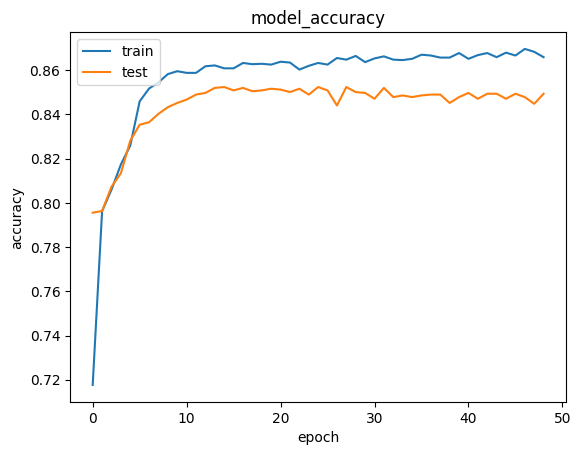

In [97]:
## Summary history for accuracy
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model_accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper left')
plt.show()

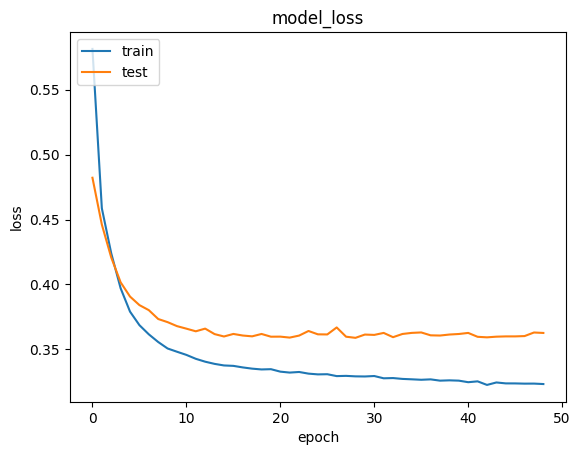

In [98]:
## Summary history for loss
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model_loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper left')
plt.show()

In [99]:
## Part 3 - Making the predictions and evaluating the model

# Predict the test set result

y_pred=classifier.predict(x_test)
y_pred=(y_pred >= 0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [100]:
## Make the confusion matrix
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)

cm

array([[1505,   90],
       [ 202,  203]])

In [101]:
## Calculate the accuracy
from sklearn.metrics import accuracy_score
score=accuracy_score(y_pred,y_test)

score

0.854

In [102]:
## get the weights
classifier.get_weights()

[array([[-0.06335384,  0.2564631 ,  0.00997268, -0.04954008,  0.12056357,
         -0.21982488,  0.0923073 ,  0.04971479,  0.0367855 ,  0.3340481 ,
          0.12284193],
        [-0.29617265, -0.95727587, -0.34018746, -0.5555883 , -0.84507316,
         -1.1083182 ,  0.42516536,  0.3585642 , -0.65824956, -0.366232  ,
         -0.28776383],
        [-0.07382892, -0.13222797,  0.13694209,  0.31859878,  0.17250137,
          0.04333542,  0.5138    ,  0.17112638, -0.13292621, -0.18045674,
         -0.4285227 ],
        [ 0.3786613 ,  0.05172378, -0.4900824 ,  0.15951012,  0.26607525,
          0.59228235, -0.16457793,  0.15895419,  0.1226683 ,  0.08357402,
         -0.5476139 ],
        [ 1.1664964 ,  0.01653727,  0.82992226,  0.28731966,  0.16773504,
          0.32531038,  1.307929  ,  0.37495792,  0.11781977,  1.0616251 ,
          0.49299124],
        [ 0.01211957,  0.2217017 , -0.16156816,  0.10034666,  0.06400058,
         -0.08934628, -0.02054375,  0.1672052 , -0.18744507,  0.0396124